In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
print("All imports successful!")

All imports successful!


In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (8799, 13)
X_test  : (2200, 13)
y_train : (8799,)
y_test  : (2200,)


In [9]:
# Define All Models

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(use_label_encoder=False,
                                          eval_metric='logloss',
                                          random_state=42)
}
print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [8]:
#  Train and Evaluate All Models

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec  * 100, 2),
        'F1 Score' : round(f1   * 100, 2),
        'AUC-ROC'  : round(auc  * 100, 2)
    })
    print(f"{name} done — Accuracy: {acc*100:.2f}%")

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n")
print(results_df.to_string(index=False))

Logistic Regression done — Accuracy: 64.82%
Decision Tree done — Accuracy: 64.18%
Random Forest done — Accuracy: 65.86%
XGBoost done — Accuracy: 64.59%


              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
      Decision Tree     64.18      69.57   71.06     70.31    62.53
            XGBoost     64.59      73.34   63.90     68.29    72.70
      Random Forest     65.86      77.28   60.62     67.95    73.12
Logistic Regression     64.82      76.50   59.25     66.78    72.76


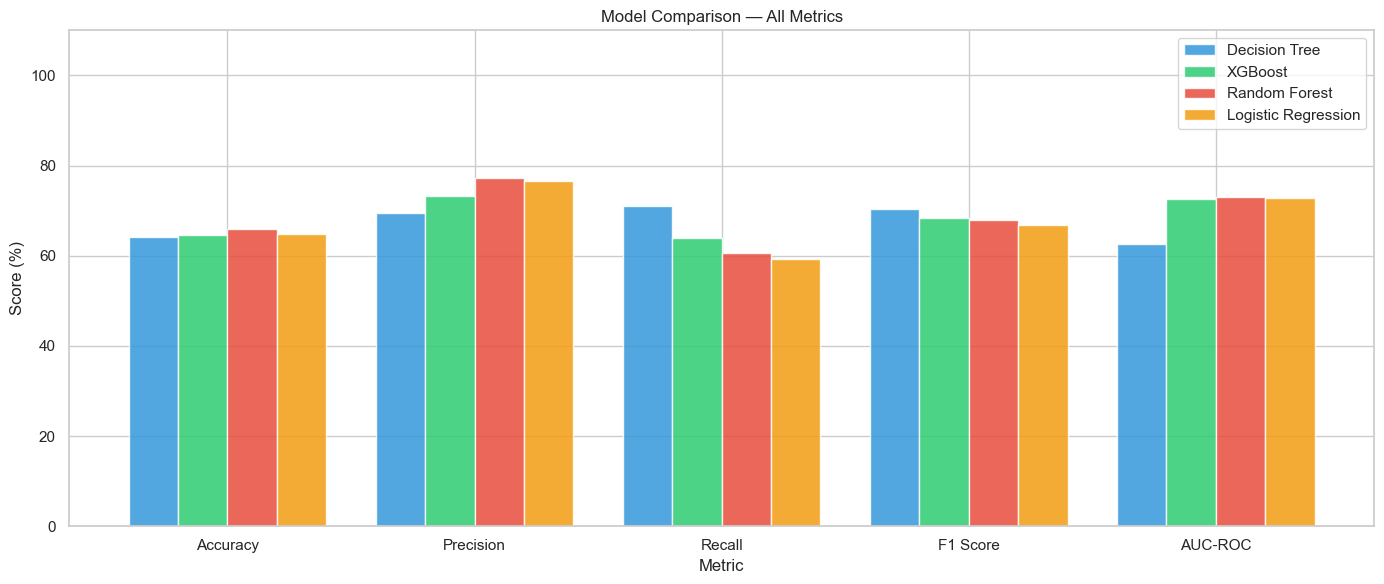

In [7]:
#  Model Comparison Chart

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('../reports/figures/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

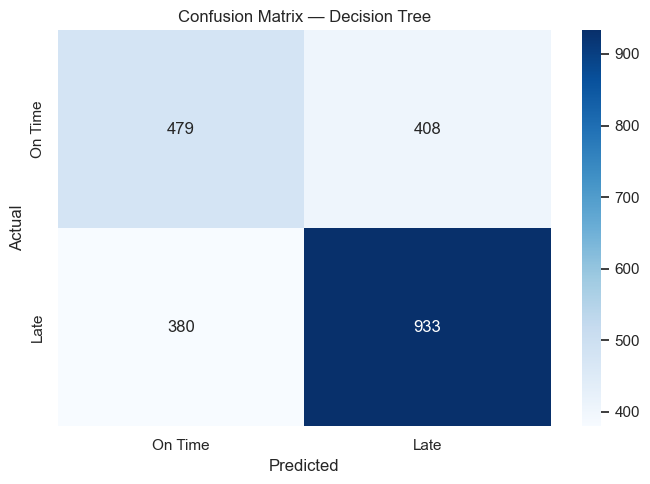


Best Model: Decision Tree

Classification Report:

              precision    recall  f1-score   support

     On Time       0.56      0.54      0.55       887
        Late       0.70      0.71      0.70      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [11]:
# Best model = highest F1 score
best_name = results_df.iloc[0]['Model']

# Retrain best model fresh to ensure it's fitted
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest Model: {best_name}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=['On Time', 'Late']))

In [13]:
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
      Decision Tree     64.18      69.57   71.06     70.31    62.53
            XGBoost     64.59      73.34   63.90     68.29    72.70
      Random Forest     65.86      77.28   60.62     67.95    73.12
Logistic Regression     64.82      76.50   59.25     66.78    72.76


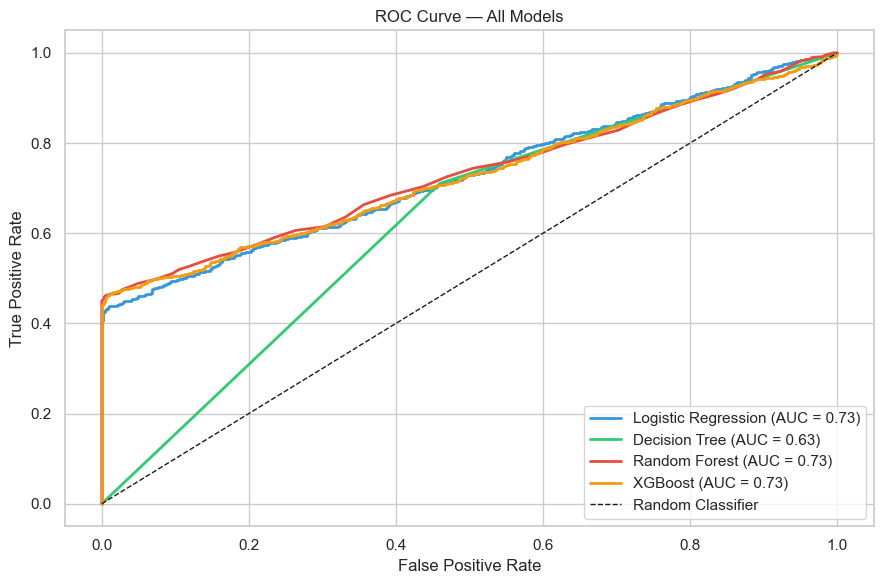

In [20]:
plt.figure(figsize=(9, 6))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
             label=f'{name} (AUC = {auc:.2f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/10_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

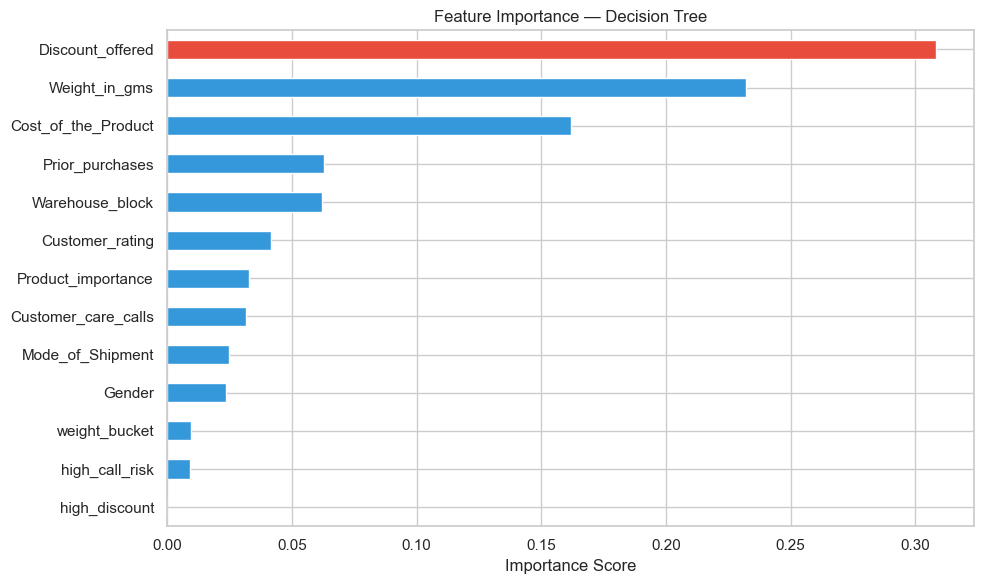

Top 5 most important features:
Discount_offered       0.308167
Weight_in_gms          0.232239
Cost_of_the_Product    0.161971
Prior_purchases        0.062726
Warehouse_block        0.062255
dtype: float64


In [22]:
# Feature Importance (Best Model)

if best_name in ['Random Forest', 'XGBoost', 'Decision Tree']:
    importance = pd.Series(best_model.feature_importances_,
                           index=X_train.columns).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    colors_imp = ['#e74c3c' if v == importance.max()
                  else '#3498db' for v in importance.values]
    importance.plot(kind='barh', color=colors_imp)
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../reports/figures/11_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 5 most important features:")
    print(importance.sort_values(ascending=False).head(5))

In [23]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.pkl')

print(f"Best model saved: {best_name}")
print(f"Location: models/best_model.pkl")
print(f"\nModel details: {best_model}")

Best model saved: Decision Tree
Location: models/best_model.pkl

Model details: DecisionTreeClassifier(random_state=42)


In [24]:
best_row = results_df.iloc[0]

print("=" * 55)
print("   MODELING COMPLETE — SHIPMENT DELAY PREDICTOR")
print("=" * 55)
print(f"\n  Best Model  : {best_row['Model']}")
print(f"  Accuracy    : {best_row['Accuracy']}%")
print(f"  Precision   : {best_row['Precision']}%")
print(f"  Recall      : {best_row['Recall']}%")
print(f"  F1 Score    : {best_row['F1 Score']}%")
print(f"  AUC-ROC     : {best_row['AUC-ROC']}%")
print(f"\n  Model saved : models/best_model.pkl")
print(f"\n  Charts saved to reports/figures/:")
print(f"    08_model_comparison.png")
print(f"    09_confusion_matrix.png")
print(f"    10_roc_curve.png")
print(f"    11_feature_importance.png")
print(f"\n  NEXT STEP: Build app/app.py (Streamlit dashboard)")
print("=" * 55)

   MODELING COMPLETE — SHIPMENT DELAY PREDICTOR

  Best Model  : Decision Tree
  Accuracy    : 64.18%
  Precision   : 69.57%
  Recall      : 71.06%
  F1 Score    : 70.31%
  AUC-ROC     : 62.53%

  Model saved : models/best_model.pkl

  Charts saved to reports/figures/:
    08_model_comparison.png
    09_confusion_matrix.png
    10_roc_curve.png
    11_feature_importance.png

  NEXT STEP: Build app/app.py (Streamlit dashboard)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Tune Random Forest
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf, param_grid, n_iter=20,
                                cv=5, scoring='f1',
                                random_state=42, n_jobs=-1, verbose=1)
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}


In [30]:
# Tune XGBoost
from xgboost import XGBClassifier

xgb_params = {
 'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2]
}

xgb = XGBClassifier(use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42)
xgb_search = RandomizedSearchCV(xgb, xgb_params, n_iter=20,
                                 cv=5, scoring='f1',
                                 random_state=42, n_jobs=-1, verbose=1)
xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [31]:
# compair the Tune Models

tuned_models = {
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)'      : best_xgb
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred)         * 100, 2),
        'Precision': round(precision_score(y_test, y_pred)        * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred)           * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred)               * 100, 2),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob)          * 100, 2)
    })
    print(f"{name} — F1: {tuned_results[-1]['F1 Score']}%")

tuned_df = pd.DataFrame(tuned_results).sort_values('F1 Score', ascending=False)
print("\n")
print(tuned_df.to_string(index=False))

Random Forest (Tuned) — F1: 68.35%
XGBoost (Tuned) — F1: 71.51%


                Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
      XGBoost (Tuned)     67.00      73.77   69.38     71.51    75.29
Random Forest (Tuned)     66.32      77.82   60.93     68.35    73.49


In [32]:
# Pick best between tuned RF and XGBoost
best_tuned_name  = tuned_df.iloc[0]['Model']
best_tuned_model = tuned_models[best_tuned_name]

joblib.dump(best_tuned_model, '../models/best_model.pkl')

print(f"New best model saved: {best_tuned_name}")
print(f"F1 Score: {tuned_df.iloc[0]['F1 Score']}%")
print("\nThis model will be used in the Streamlit dashboard.")

New best model saved: XGBoost (Tuned)
F1 Score: 71.51%

This model will be used in the Streamlit dashboard.
